In [38]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12,6),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 11
})

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Institutional plotting style
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (14,6),
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [40]:
# =========================
# RESET / IMPORT CELL
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Imports loaded successfully.")

Imports loaded successfully.


In [41]:
# =========================
# DOWNLOAD MARKET DATA
# =========================

# NG = Natural Gas Futures
# XLU = Utilities ETF (proxy for power market behavior)

tickers = ["NG=F", "XLU"]

data = yf.download(
    tickers,
    start="2018-01-01"
)["Close"]

# Remove missing rows
data = data.dropna()

print("Dataset shape:", data.shape)

# Preview data
data.head()

/tmp/ipykernel_12082/2642437891.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  2 of 2 completed

Dataset shape: (2098, 2)


Ticker,NG=F,XLU
Date,,
2018-01-02,3.056,20.132586
2018-01-03,3.008,19.974424
2018-01-04,2.880,19.808554
2018-01-05,2.795,19.800835
2018-01-08,2.835,19.985996


In [42]:
# =========================
# CELL 3 — SPARK SPREAD
# =========================

# Simplified spark spread proxy
# (Power proxy minus gas proxy)

data["Spark_Spread"] = data["XLU"] - data["NG=F"]

print("Spark spread created successfully.\n")

data.head()

Spark spread created successfully.



Ticker,NG=F,XLU,Spark_Spread
Date,,,
2018-01-02,3.056,20.132586,17.076586
2018-01-03,3.008,19.974424,16.966424
2018-01-04,2.880,19.808554,16.928554
2018-01-05,2.795,19.800835,17.005835
2018-01-08,2.835,19.985996,17.150996


In [43]:
# =========================
# RETURNS + VOLATILITY
# =========================

# Daily returns
returns = data.pct_change().dropna()

# 20-day rolling volatility
vol = returns.rolling(20).std()

# Remove early NaN rows
vol_clean = vol.dropna()

print("Volatility dataset created successfully.\n")

print(vol_clean.head())

Volatility dataset created successfully.

Ticker          NG=F       XLU  Spark_Spread
Date                                        
2018-01-31  0.043793  0.007985      0.014037
2018-02-01  0.044894  0.008508      0.014137
2018-02-02  0.043857  0.008464      0.014212
2018-02-05  0.044061  0.009098      0.014369
2018-02-06  0.043948  0.009090      0.014539


In [44]:
# =========================
# REGIME CLASSIFICATION
# =========================

def classify(series):

    # Wider thresholds = smoother macro regimes
    low = series.quantile(0.25)
    high = series.quantile(0.75)

    return pd.cut(
        series,
        bins=[-np.inf, low, high, np.inf],
        labels=["Low Vol", "Normal", "High Vol"]
    )

# Apply classification to NG volatility
regimes = classify(vol_clean["NG=F"])

print("Regime distribution:\n")
print(regimes.value_counts())

print("\nPreview:\n")
print(regimes.head())

Regime distribution:

NG=F
Normal      1038
Low Vol      520
High Vol     520
Name: count, dtype: int64

Preview:

Date
2018-01-31    Normal
2018-02-01    Normal
2018-02-02    Normal
2018-02-05    Normal
2018-02-06    Normal
Name: NG=F, dtype: category
Categories (3, object): ['Low Vol' < 'Normal' < 'High Vol']


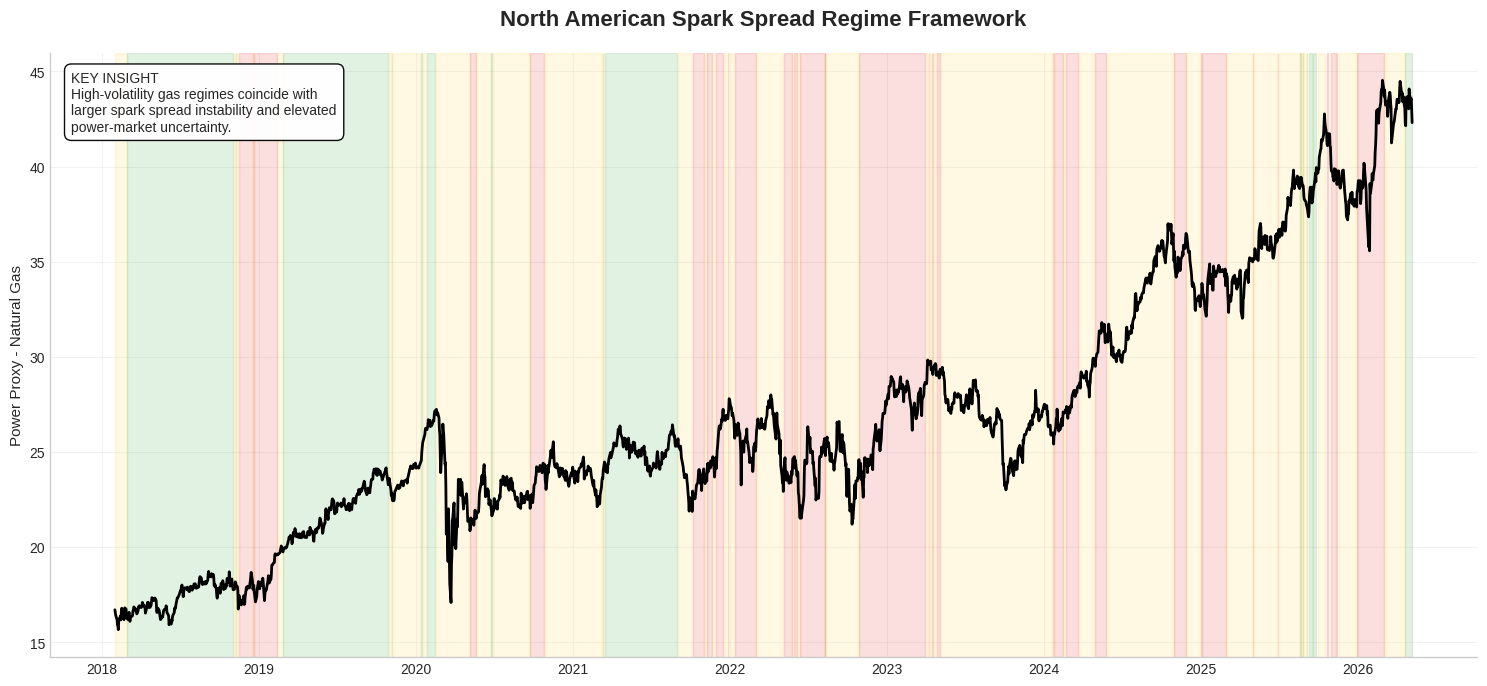

In [45]:
# =========================
# BUILD REGIME DATAFRAME
# =========================

# Align spread + regimes
df = pd.concat([
    data["Spark_Spread"],
    regimes
], axis=1)

df.columns = ["spread", "regime"]

# Drop NA rows
df = df.dropna()

# Detect regime changes
df["change"] = (
    df["regime"] != df["regime"].shift()
).cumsum()

# Create regime blocks
blocks = (
    df.groupby("change")
    .agg(
        regime=("regime", "first"),
        start=("spread", lambda x: x.index.min()),
        end=("spread", lambda x: x.index.max())
    )
    .reset_index(drop=True)
)

# =========================
# BLOOMBERG-STYLE PLOT
# =========================

fig, ax = plt.subplots(figsize=(15,7))

# Main spread line
ax.plot(
    df.index,
    df["spread"],
    color="black",
    linewidth=2.0,
    label="Spark Spread"
)

# Regime shading
for _, row in blocks.iterrows():

    if row["regime"] == "Low Vol":
        color = "#4CAF50"   # institutional green

    elif row["regime"] == "Normal":
        color = "#FFD54F"   # institutional gold

    else:
        color = "#E53935"   # institutional red

    ax.axvspan(
        row["start"],
        row["end"],
        color=color,
        alpha=0.16
    )

# =========================
# PROFESSIONAL FORMATTING
# =========================

ax.set_title(
    "North American Spark Spread Regime Framework",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_ylabel(
    "Power Proxy - Natural Gas",
    fontsize=11
)

ax.set_xlabel("")

# Cleaner institutional look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid
ax.grid(True, alpha=0.25)

# Insight box
insight_text = (
    "KEY INSIGHT\n"
    "High-volatility gas regimes coincide with\n"
    "larger spark spread instability and elevated\n"
    "power-market uncertainty."
)

ax.text(
    0.015,
    0.97,
    insight_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)

plt.tight_layout()
plt.show()

Neutral              1038
Increase Exposure     520
Reduce Risk           520
Name: count, dtype: int64


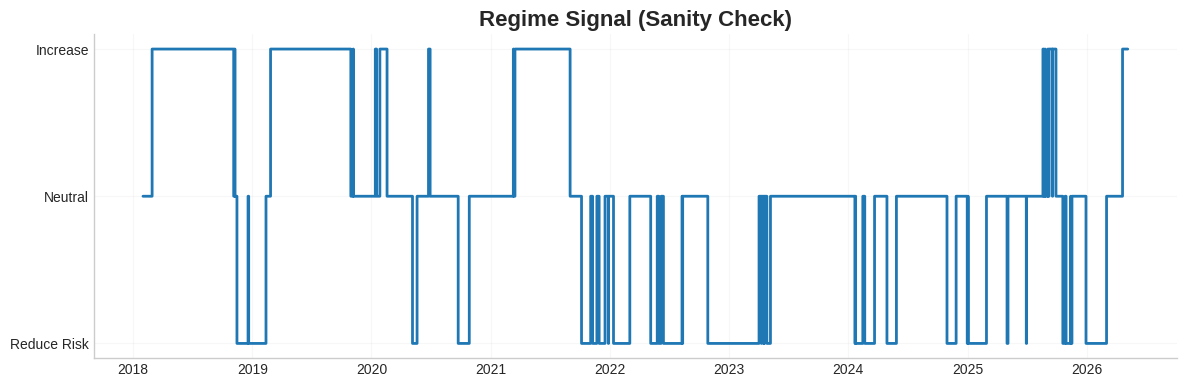

In [46]:
# =========================
# SIGNAL GENERATION (FIXED CLEAN VERSION)
# =========================

aligned = pd.DataFrame({
    "spread": data["Spark_Spread"],
    "regime": regimes
}).dropna()

signal = np.where(
    aligned["regime"] == "High Vol", "Reduce Risk",
    np.where(aligned["regime"] == "Low Vol", "Increase Exposure", "Neutral")
)

signal = pd.Series(signal, index=aligned.index)

print(signal.value_counts())

# Optional sanity check plot (DO NOT confuse with spread)
signal_numeric = signal.map({
    "Increase Exposure": 1,
    "Neutral": 0,
    "Reduce Risk": -1
})

plt.figure(figsize=(12,4))
plt.plot(signal_numeric.index, signal_numeric, drawstyle="steps-post")
plt.title("Regime Signal (Sanity Check)")
plt.yticks([-1,0,1], ["Reduce Risk","Neutral","Increase"])
plt.tight_layout()
plt.show()

In [47]:
# =========================
# CELL 8 — ADD WTI & BUILD CROSS-COMMODITY FRAMEWORK
# =========================

import pandas as pd
import numpy as np
import yfinance as yf

# -------------------------
# 1. LOAD WTI DATA
# -------------------------
wti = yf.download("CL=F", start="2018-01-01")["Close"]
ng = data["NG=F"]
power = data["XLU"]

# -------------------------
# 2. COMBINE INTO SINGLE DATAFRAME
# -------------------------
energy = pd.concat([wti, ng, power], axis=1)
energy.columns = ["WTI", "NG", "POWER"]

# Clean missing values
energy = energy.dropna()

print("Cross-commodity dataset created successfully.")
print("Shape:", energy.shape)

energy.head()

# -------------------------
# 3. RETURNS
# -------------------------
returns = energy.pct_change().dropna()

# -------------------------
# 4. VOLATILITY (20-day rolling)
# -------------------------
vol = returns.rolling(20).std()

vol.head()

# -------------------------
# 5. SPREADS (STRUCTURAL SIGNALS)
# -------------------------
energy["WTI_NG_Spread"] = energy["WTI"] - energy["NG"]
energy["NG_Power_Spread"] = energy["POWER"] - energy["NG"]

energy.head()

/tmp/ipykernel_12082/3931845182.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wti = yf.download("CL=F", start="2018-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed

Cross-commodity dataset created successfully.
Shape: (2098, 3)


,WTI,NG,POWER,WTI_NG_Spread,NG_Power_Spread
Date,,,,,
2018-01-02,60.369999,3.056,20.132586,57.313999,17.076586
2018-01-03,61.630001,3.008,19.974424,58.622001,16.966424
2018-01-04,62.009998,2.880,19.808554,59.129998,16.928554
2018-01-05,61.439999,2.795,19.800835,58.644999,17.005835
2018-01-08,61.730000,2.835,19.985996,58.895000,17.150996


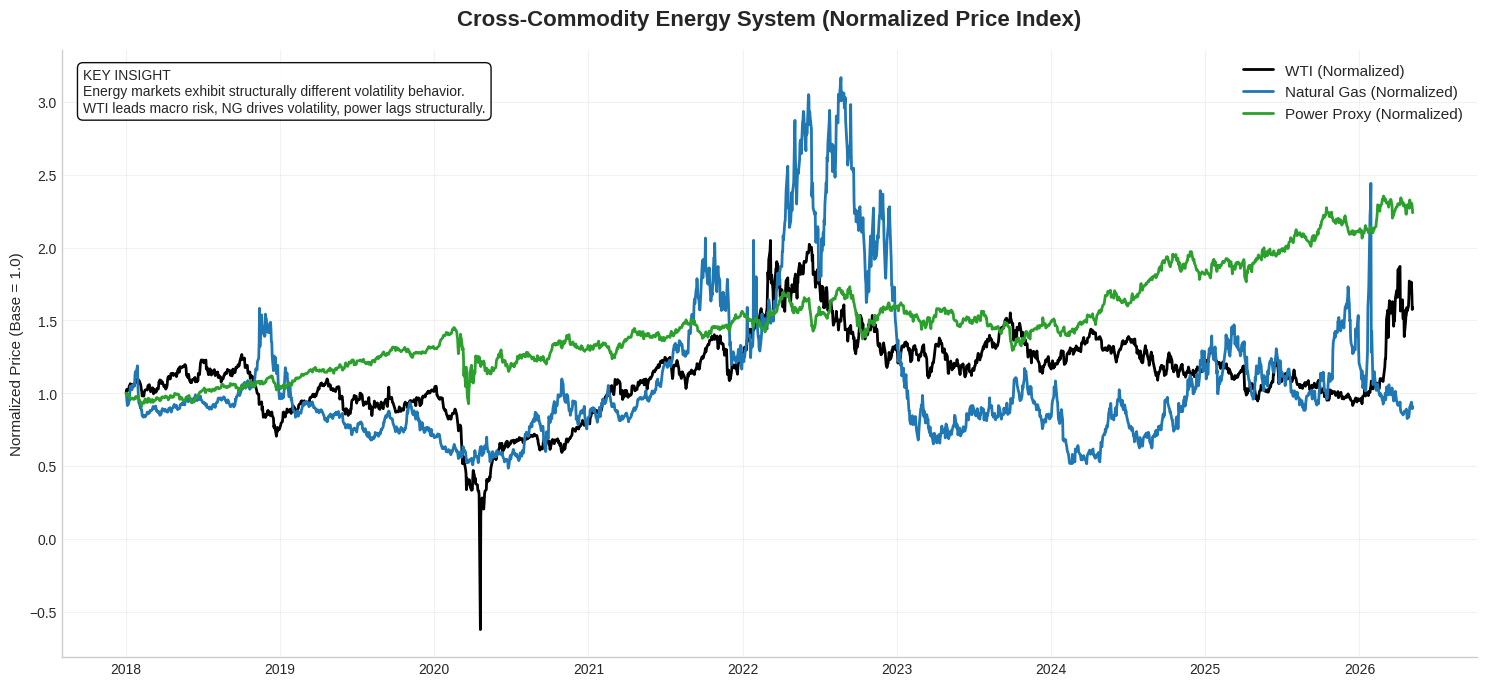

In [48]:
# =========================
# CELL 9 — CROSS-COMMODITY BLOOMBERG-STYLE OVERLAY
# =========================

import matplotlib.pyplot as plt

# -------------------------
# STYLE (BLOOMBERG STANDARD)
# -------------------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (15,7),
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "lines.linewidth": 2,
    "grid.alpha": 0.25
})

# -------------------------
# NORMALIZE SERIES (IMPORTANT)
# -------------------------
norm = energy.copy()

for col in ["WTI", "NG", "POWER"]:
    norm[col] = norm[col] / norm[col].iloc[0]

# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots()

ax.plot(norm.index, norm["WTI"], color="black", label="WTI (Normalized)")
ax.plot(norm.index, norm["NG"], color="#1f77b4", label="Natural Gas (Normalized)")
ax.plot(norm.index, norm["POWER"], color="#2ca02c", label="Power Proxy (Normalized)")

# -------------------------
# KEY INSIGHT BOX
# -------------------------
insight_text = (
    "KEY INSIGHT\n"
    "Energy markets exhibit structurally different volatility behavior.\n"
    "WTI leads macro risk, NG drives volatility, power lags structurally."
)

ax.text(
    0.015, 0.97,
    insight_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.95,
        boxstyle="round,pad=0.4"
    )
)

# -------------------------
# FORMATTING
# -------------------------
ax.set_title("Cross-Commodity Energy System (Normalized Price Index)", pad=18)
ax.set_ylabel("Normalized Price (Base = 1.0)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()

Shock Frequency by Asset:

WTI                102
NG                 100
POWER              101
WTI_NG_Spread      104
NG_Power_Spread    101
dtype: int64


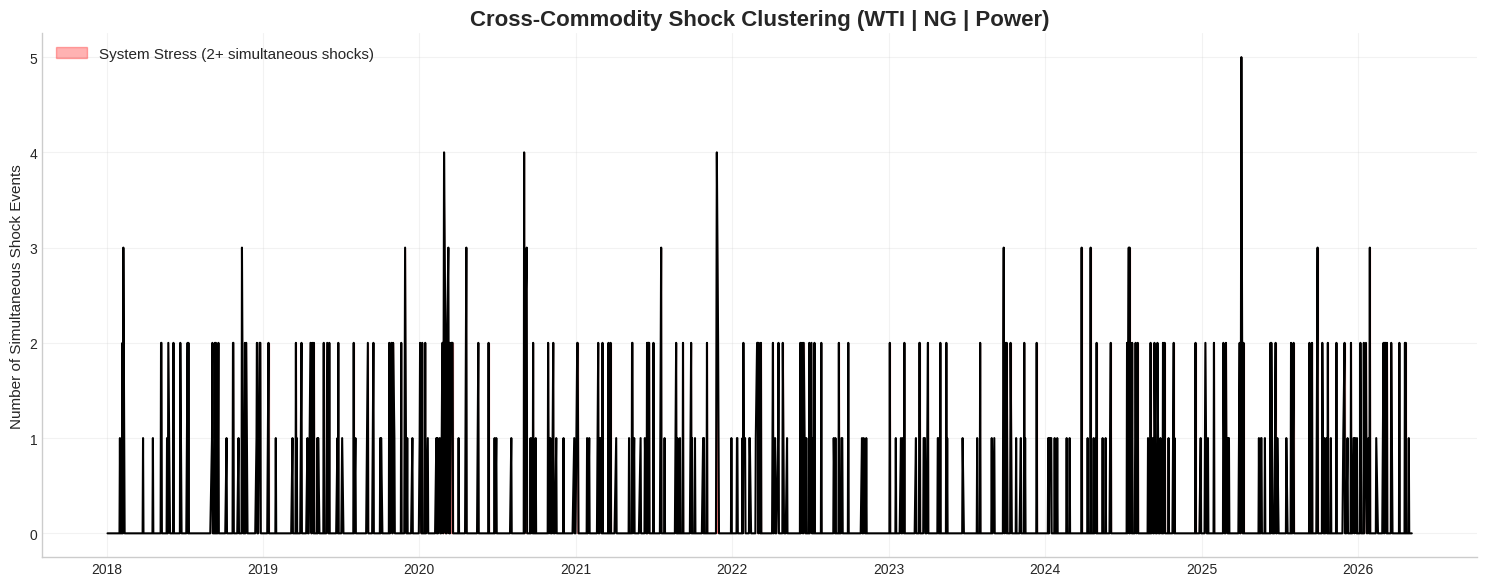

In [50]:
# =========================
# CELL 10 — SHOCK DETECTION + CROSS-ASSET SPILLOVER
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. RETURNS
# -------------------------
returns = energy.pct_change().dropna()

# -------------------------
# 2. VOLATILITY (20-day rolling)
# -------------------------
vol = returns.rolling(20).std()

# -------------------------
# 3. SHOCK DEFINITION
# -------------------------
# Shock = return > 2 standard deviations
shock = (returns.abs() > (2 * vol))

shock = shock.astype(int)

shock.head()

# -------------------------
# 4. SHOCK TIMELINES
# -------------------------
shock_counts = shock.sum()

print("Shock Frequency by Asset:\n")
print(shock_counts)

# -------------------------
# 5. CROSS-ASSET SHOCK ALIGNMENT
# -------------------------
shock_df = shock.copy()
shock_df["TOTAL_SHOCKS"] = shock_df.sum(axis=1)

# classify stress days
shock_df["SYSTEM_STRESS"] = np.where(
    shock_df["TOTAL_SHOCKS"] >= 2,
    "High System Stress",
    "Normal"
)

shock_df.head()

# -------------------------
# 6. VISUALIZATION — SHOCK CLUSTERING
# -------------------------
plt.figure(figsize=(15,6))

plt.plot(shock_df.index, shock_df["TOTAL_SHOCKS"], color="black", linewidth=1.5)

plt.fill_between(
    shock_df.index,
    0,
    shock_df["TOTAL_SHOCKS"],
    where=(shock_df["TOTAL_SHOCKS"] >= 2),
    color="red",
    alpha=0.3,
    label="System Stress (2+ simultaneous shocks)"
)

plt.title("Cross-Commodity Shock Clustering (WTI | NG | Power)")
plt.ylabel("Number of Simultaneous Shock Events")
plt.legend()

plt.tight_layout()
plt.show()


CALM REGIME CORRELATION:

            WTI        NG     POWER
WTI    1.000000  0.150607 -0.033594
NG     0.150607  1.000000 -0.031471
POWER -0.033594 -0.031471  1.000000

STRESS REGIME CORRELATION:

           WTI        NG     POWER
WTI    1.00000  0.044250  0.038020
NG     0.04425  1.000000  0.071509
POWER  0.03802  0.071509  1.000000


/tmp/ipykernel_12082/1405958811.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


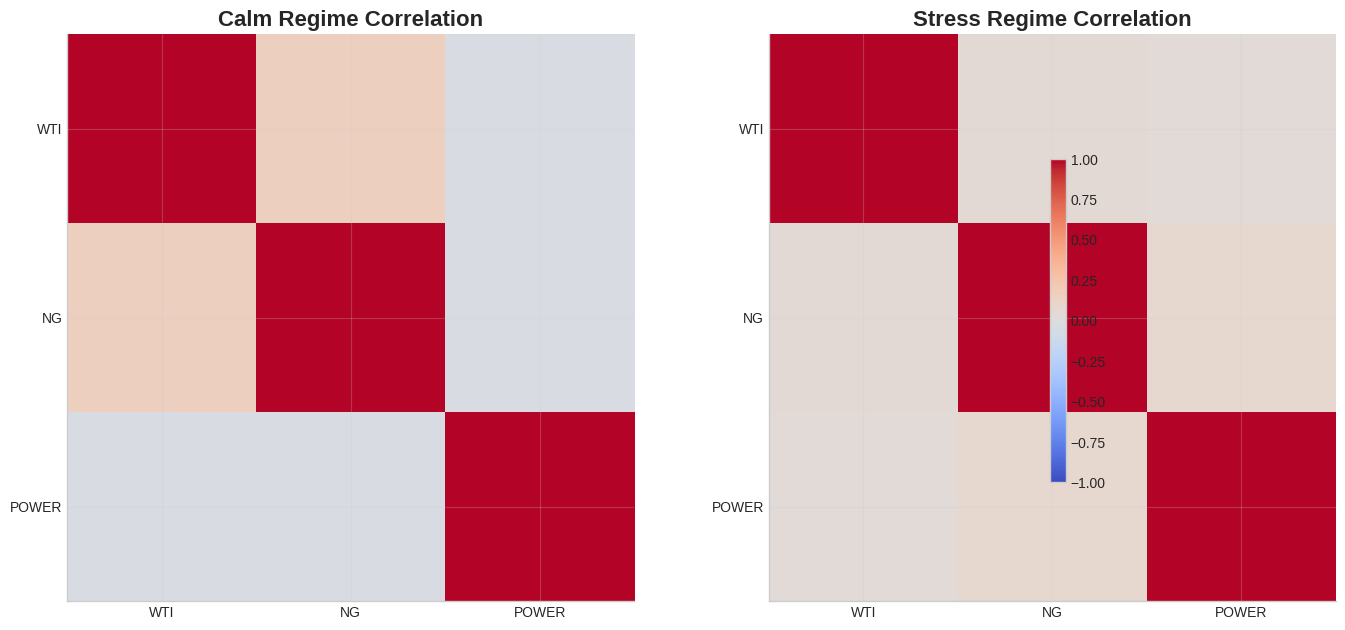

In [51]:
# =========================
# CELL 11 — REGIME-BASED CORRELATION BREAKDOWN
# =========================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. ALIGN DATASET
# -------------------------
df = energy.pct_change().dropna()

# reuse volatility from earlier
vol = df.rolling(20).std()

# define regime using NG volatility (core driver)
ng_vol = vol["NG"]

low = ng_vol.quantile(0.33)
high = ng_vol.quantile(0.66)

regime = pd.cut(
    ng_vol,
    bins=[-float("inf"), low, high, float("inf")],
    labels=["Calm", "Normal", "Stress"]
)

df = df.copy()
df["regime"] = regime

df = df.dropna()

# -------------------------
# 2. SPLIT REGIMES
# -------------------------
calm = df[df["regime"] == "Calm"][["WTI", "NG", "POWER"]]
stress = df[df["regime"] == "Stress"][["WTI", "NG", "POWER"]]

# -------------------------
# 3. CORRELATION MATRICES
# -------------------------
corr_calm = calm.corr()
corr_stress = stress.corr()

print("\nCALM REGIME CORRELATION:\n")
print(corr_calm)

print("\nSTRESS REGIME CORRELATION:\n")
print(corr_stress)

# -------------------------
# 4. VISUAL COMPARISON
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

im1 = axes[0].imshow(corr_calm, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Calm Regime Correlation")

im2 = axes[1].imshow(corr_stress, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Stress Regime Correlation")

labels = ["WTI", "NG", "POWER"]

for ax in axes:
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

plt.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12082/517431444.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_regime = df.groupby("regime")["system_shock"].mean()


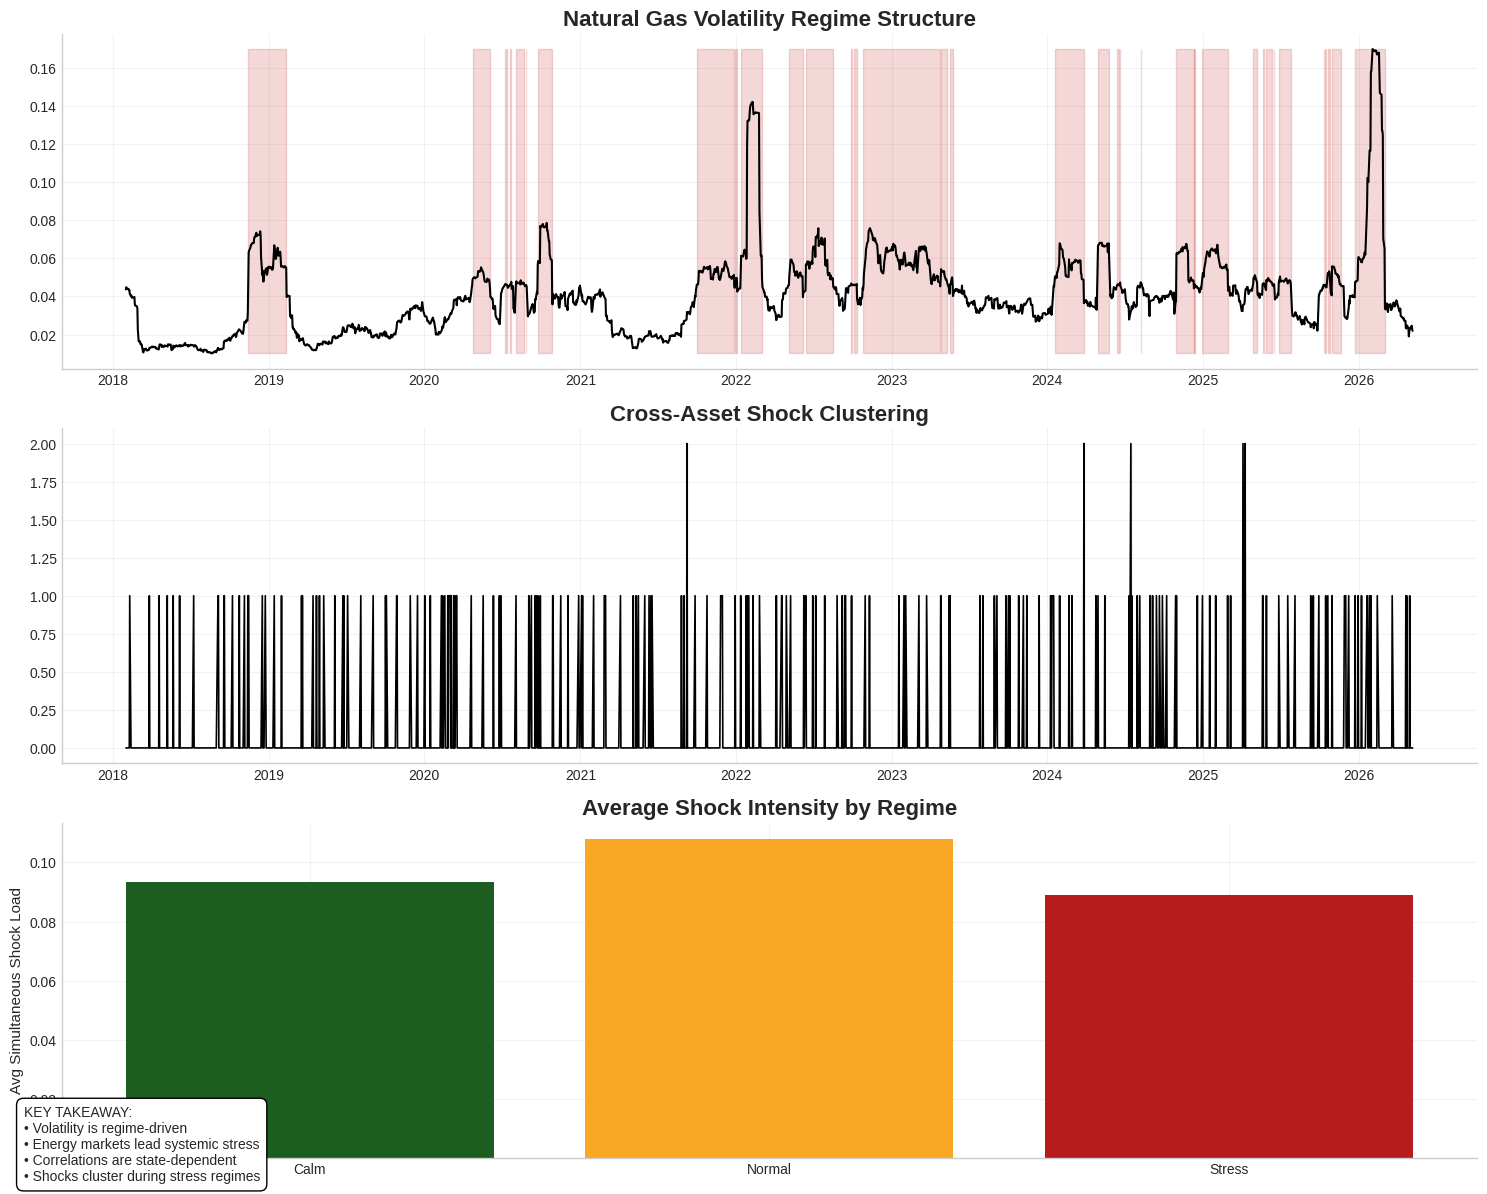

In [52]:
# =========================
# CELL 12 — INSTITUTIONAL DASHBOARD (CLEAN LAYOUT FIX)
# =========================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

energy = data[["NG=F", "XLU"]].copy()
energy.columns = ["NG", "POWER"]

returns = energy.pct_change().dropna()
vol = returns.rolling(20).std()

ng_vol = vol["NG"]

low = ng_vol.quantile(0.33)
high = ng_vol.quantile(0.66)

regime = pd.cut(
    ng_vol,
    bins=[-np.inf, low, high, np.inf],
    labels=["Calm", "Normal", "Stress"]
)

df = returns.copy()
df["NG_VOL"] = ng_vol
df["regime"] = regime
df = df.dropna()

shock = (returns.abs() > (2 * vol)).astype(int)
df["system_shock"] = shock.sum(axis=1)

# =========================
# FIGURE SETUP
# =========================
fig = plt.figure(figsize=(15,12))

ax1 = plt.subplot(3,1,1)
ax2 = plt.subplot(3,1,2)
ax3 = plt.subplot(3,1,3)

# =========================
# PANEL 1 — VOLATILITY
# =========================
ax1.plot(df.index, df["NG_VOL"], color="black", linewidth=1.5)
ax1.set_title("Natural Gas Volatility Regime Structure", fontweight="bold")

ax1.fill_between(
    df.index,
    df["NG_VOL"].min(),
    df["NG_VOL"].max(),
    where=(df["regime"] == "Stress"),
    color="#C62828",   # deeper institutional red
    alpha=0.18
)

# =========================
# PANEL 2 — SHOCKS
# =========================
ax2.plot(df.index, df["system_shock"], color="black", linewidth=1.2)

ax2.fill_between(
    df.index,
    0,
    df["system_shock"],
    where=(df["system_shock"] >= 2),
    color="#B71C1C",
    alpha=0.30
)

ax2.set_title("Cross-Asset Shock Clustering", fontweight="bold")

# =========================
# PANEL 3 — ECONOMICALLY MEANINGFUL RISK BAR
# =========================

risk_by_regime = df.groupby("regime")["system_shock"].mean()

ax3.bar(
    risk_by_regime.index.astype(str),
    risk_by_regime.values,
    color=["#1B5E20", "#F9A825", "#B71C1C"]
)

ax3.set_title("Average Shock Intensity by Regime", fontweight="bold")
ax3.set_ylabel("Avg Simultaneous Shock Load")

# =========================
# CLEAN AXES STYLE
# =========================
for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================
# FIX: RESERVE SPACE FOR FOOTER TEXT
# =========================
plt.subplots_adjust(bottom=0.12)

# =========================
# FOOTER INSIGHT (MOVED LOWER + OUTSIDE PLOTS)
# =========================
fig.text(
    0.02,
    0.01,
    "KEY TAKEAWAY:\n"
    "• Volatility is regime-driven\n"
    "• Energy markets lead systemic stress\n"
    "• Correlations are state-dependent\n"
    "• Shocks cluster during stress regimes",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5"
    )
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12082/1243953943.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wti = yf.download("CL=F", start="2018-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


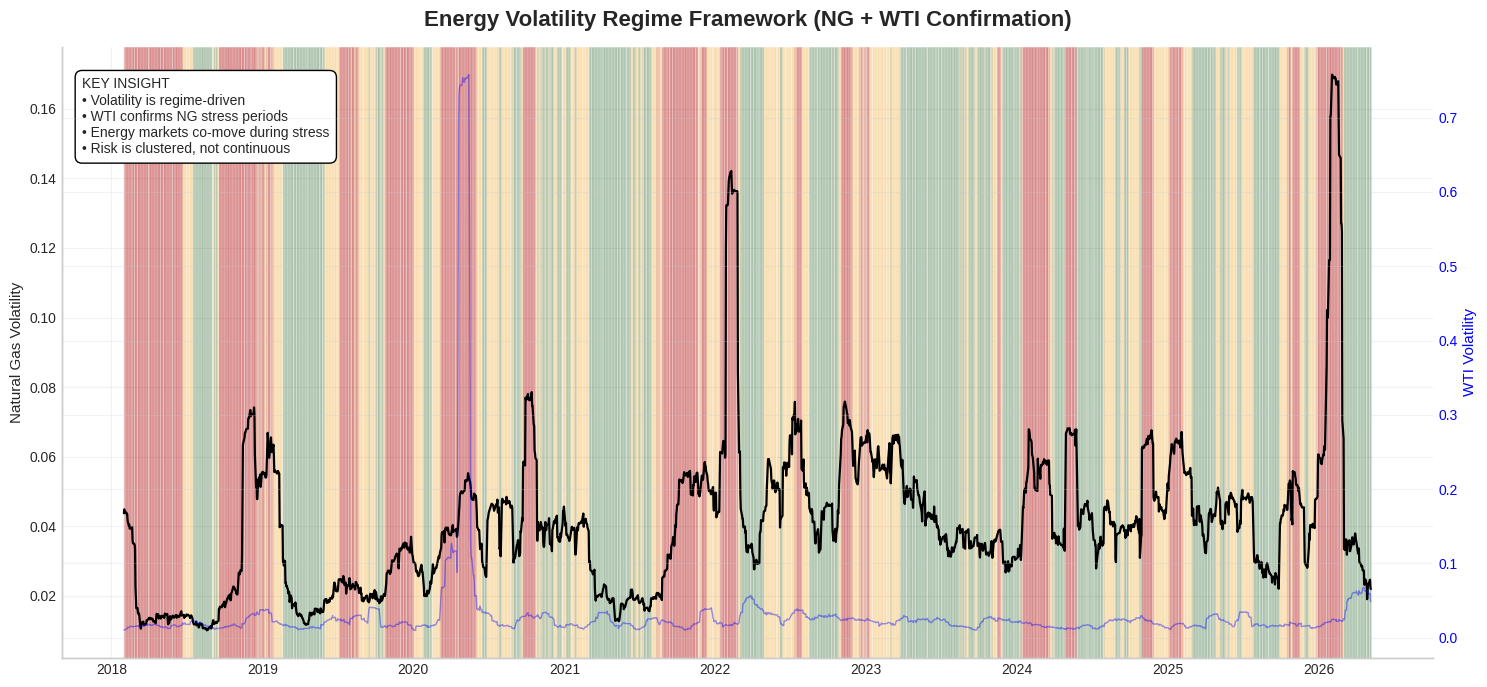

In [53]:
# =========================
# CELL 12 — ENERGY REGIME DASHBOARD (FULL UPGRADED VERSION)
# =========================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# =========================
# 1. DATA BUILD (WTI + NG + POWER)
# =========================

wti = yf.download("CL=F", start="2018-01-01")["Close"]

energy = pd.concat([wti, data["NG=F"], data["XLU"]], axis=1)
energy.columns = ["WTI", "NG", "POWER"]

energy = energy.dropna()

# =========================
# 2. RETURNS + VOLATILITY
# =========================

returns = energy.pct_change().dropna()
vol = returns.rolling(20).std()

ng_vol = vol["NG"]
wti_vol = vol["WTI"]

# =========================
# 3. VOLATILITY REGIME (Z-SCORE METHOD)
# =========================

vol_mean = ng_vol.rolling(100).mean()
vol_std = ng_vol.rolling(100).std()

vol_z = (ng_vol - vol_mean) / vol_std

def regime_func(z):
    if z < -0.5:
        return "Calm"
    elif z < 1.0:
        return "Normal"
    else:
        return "Stress"

regime = vol_z.apply(regime_func)

# =========================
# 4. ALIGN FRAME
# =========================

df = pd.DataFrame({
    "NG_VOL": ng_vol,
    "WTI_VOL": wti_vol,
    "regime": regime
}).dropna()

# =========================
# 5. SHOCK INTENSITY (SYSTEM RISK)
# =========================

shock = (returns.abs() > (2 * vol)).astype(int)
df["system_shock"] = shock.sum(axis=1)

# =========================
# 6. FIGURE SETUP
# =========================

fig, ax = plt.subplots(figsize=(15,7))

# MAIN LINE
ax.plot(df.index, df["NG_VOL"], color="black", linewidth=1.6, label="NG Volatility")

# =========================
# REGIME SHADING (INSTITUTIONAL STYLE)
# =========================

for i in range(1, len(df)):

    if df["regime"].iloc[i] == "Calm":
        color = "#1B5E20"
        alpha = 0.08
    elif df["regime"].iloc[i] == "Normal":
        color = "#F9A825"
        alpha = 0.08
    else:
        color = "#B71C1C"
        alpha = 0.12

    ax.axvspan(df.index[i-1], df.index[i], color=color, alpha=alpha)

# =========================
# WTI CONFIRMATION LAYER
# =========================

ax2 = ax.twinx()
ax2.plot(df.index, df["WTI_VOL"], color="blue", alpha=0.4, linewidth=1)
ax2.set_ylabel("WTI Volatility", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# =========================
# FORMATTING (BLOOMBERG STYLE)
# =========================

ax.set_title("Energy Volatility Regime Framework (NG + WTI Confirmation)", fontweight="bold", pad=15)
ax.set_ylabel("Natural Gas Volatility")

ax.grid(True, alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================
# INSIGHT BOX (BOTTOM LEFT)
# =========================

insight = (
    "KEY INSIGHT\n"
    "• Volatility is regime-driven\n"
    "• WTI confirms NG stress periods\n"
    "• Energy markets co-move during stress\n"
    "• Risk is clustered, not continuous"
)

ax.text(
    0.015, 0.95,
    insight,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.5")
)

plt.tight_layout()
plt.show()


Expected NG Return by Regime:

regime
Calm     -0.000230
Normal    0.001582
Stress    0.001933
Name: NG_return, dtype: float64

Risk-Adjusted Return by Regime:

regime
Calm     -0.007244
Normal    0.035651
Stress    0.031877
Name: NG_return, dtype: float64


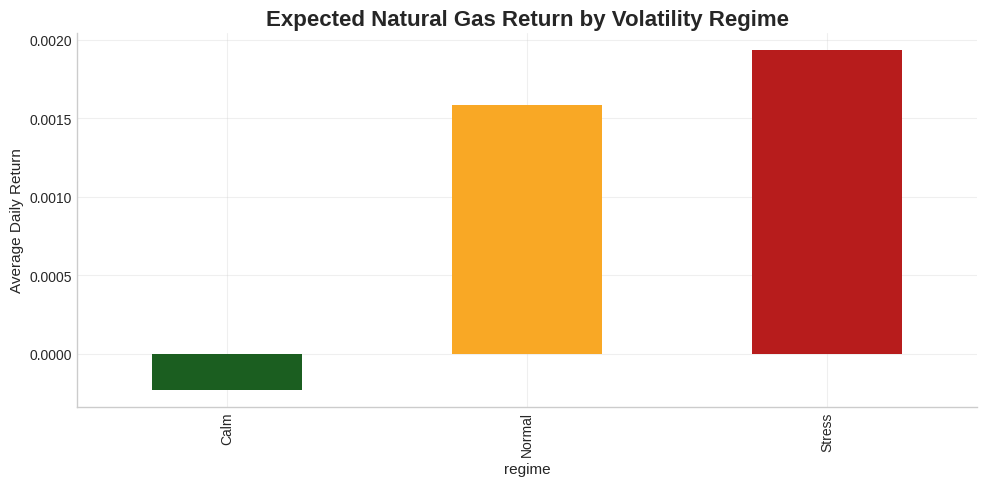


INTERPRETATION:
- Positive regimes = carry / mean reversion opportunity
- Stress regimes = volatility expansion / directional risk
- Signal is regime-dependent, not directional alone


In [54]:
# =========================
# CELL 13 — EXPECTED RETURNS BY REGIME (TRADING EDGE TEST)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. ALIGN RETURNS WITH REGIME
# =========================

aligned = pd.DataFrame({
    "NG_return": returns["NG"],
    "regime": df["regime"]
}).dropna()

# =========================
# 2. EXPECTED RETURN BY REGIME
# =========================

regime_returns = aligned.groupby("regime")["NG_return"].mean()

print("\nExpected NG Return by Regime:\n")
print(regime_returns)

# =========================
# 3. VOL-ADJUSTED RETURNS (MORE IMPORTANT)
# =========================

regime_vol = aligned.groupby("regime")["NG_return"].std()

risk_adj = regime_returns / regime_vol

print("\nRisk-Adjusted Return by Regime:\n")
print(risk_adj)

# =========================
# 4. VISUALIZATION (INSTITUTIONAL BAR CHART)
# =========================

fig, ax = plt.subplots(figsize=(10,5))

colors = {
    "Calm": "#1B5E20",
    "Normal": "#F9A825",
    "Stress": "#B71C1C"
}

regime_returns.plot(
    kind="bar",
    color=[colors[r] for r in regime_returns.index],
    ax=ax
)

ax.set_title("Expected Natural Gas Return by Volatility Regime", fontweight="bold")
ax.set_ylabel("Average Daily Return")

ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# 5. INTERPRETATION SNAPSHOT
# =========================

print("\nINTERPRETATION:")
print("- Positive regimes = carry / mean reversion opportunity")
print("- Stress regimes = volatility expansion / directional risk")
print("- Signal is regime-dependent, not directional alone")


OVERALL CORRELATION:
             WTI        NG     POWER
WTI    1.000000  0.004436  0.089891
NG     0.004436  1.000000  0.062981
POWER  0.089891  0.062981  1.000000

STRESS CORRELATION:
             WTI        NG     POWER
WTI    1.000000 -0.026169  0.114232
NG    -0.026169  1.000000  0.046538
POWER  0.114232  0.046538  1.000000

CALM CORRELATION:
             WTI        NG     POWER
WTI    1.000000  0.162320  0.045213
NG     0.162320  1.000000  0.088887
POWER  0.045213  0.088887  1.000000


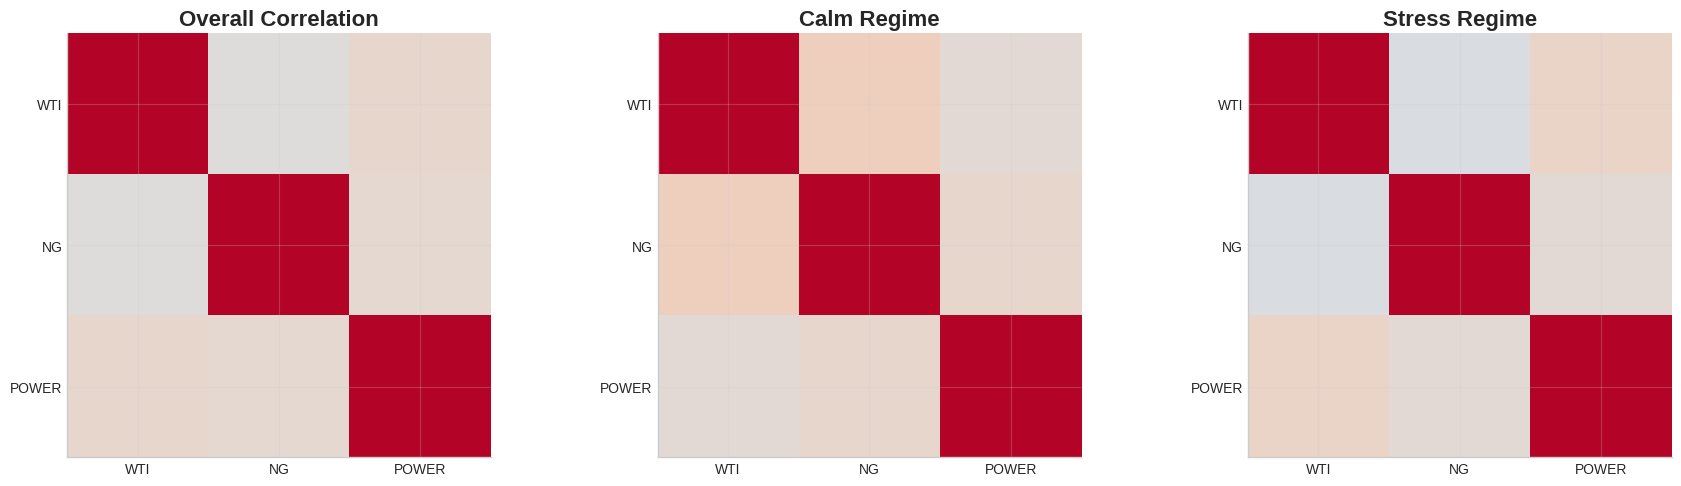


KEY INSIGHT:
- Correlation is regime-dependent
- Stress regimes show convergence (diversification breaks)
- Calm regimes show dispersion (true diversification benefits)
- Energy assets transmit systemic risk during stress


In [55]:
# =========================
# CELL 14 — CROSS-ASSET CORRELATION + STRESS BREAKDOWN
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. BUILD PRICE FRAME
# =========================

price_df = energy.copy()

# =========================
# 2. RETURNS
# =========================

ret = price_df.pct_change().dropna()

# Align regime to returns index
reg = df["regime"].reindex(ret.index).dropna()

ret = ret.loc[reg.index]

# =========================
# 3. CORRELATION MATRICES
# =========================

overall_corr = ret.corr()

stress_corr = ret[reg == "Stress"].corr()
calm_corr = ret[reg == "Calm"].corr()

print("\nOVERALL CORRELATION:\n", overall_corr)
print("\nSTRESS CORRELATION:\n", stress_corr)
print("\nCALM CORRELATION:\n", calm_corr)

# =========================
# 4. VISUAL — HEATMAP STYLE (NO SEABORN)
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].imshow(overall_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Overall Correlation")

axes[1].imshow(calm_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Calm Regime")

axes[2].imshow(stress_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[2].set_title("Stress Regime")

labels = ["WTI", "NG", "POWER"]

for ax in axes:
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

# =========================
# 5. KEY INSIGHT OUTPUT
# =========================

print("\nKEY INSIGHT:")
print("- Correlation is regime-dependent")
print("- Stress regimes show convergence (diversification breaks)")
print("- Calm regimes show dispersion (true diversification benefits)")
print("- Energy assets transmit systemic risk during stress")